In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import sigpy.mri as mr
import numpy as np
import os
import time
import jax as jx
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

print(project_root)

import aymansigmri as asm

/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE


## Goal: Implement Algorithm 4.1

In [2]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=50
indiv2 = int(inner_wid/2)

### Set up ZTE style data

In [3]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = asm.inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)


im_grid0 = sp.ifft(cartesian_zte, axes=(-2, -1))
preloop = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

zte_radial_kspace1, zte_radial_coords1 = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=0, undersampling_factor=1)
cartesian_nogap = asm.nufft_gridding(kspace=zte_radial_kspace1, coords=zte_radial_coords1)

dcf1 = (zte_radial_coords1[...,0]**2 + zte_radial_coords1[...,1]**2)**0.5
im_grid3 = sp.nufft_adjoint(zte_radial_kspace1* dcf1, zte_radial_coords1)
img_nogap = np.sum(np.abs(im_grid3)**2, axis=0)**0.5

### Build and plot mask - same as in cartesian testing

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


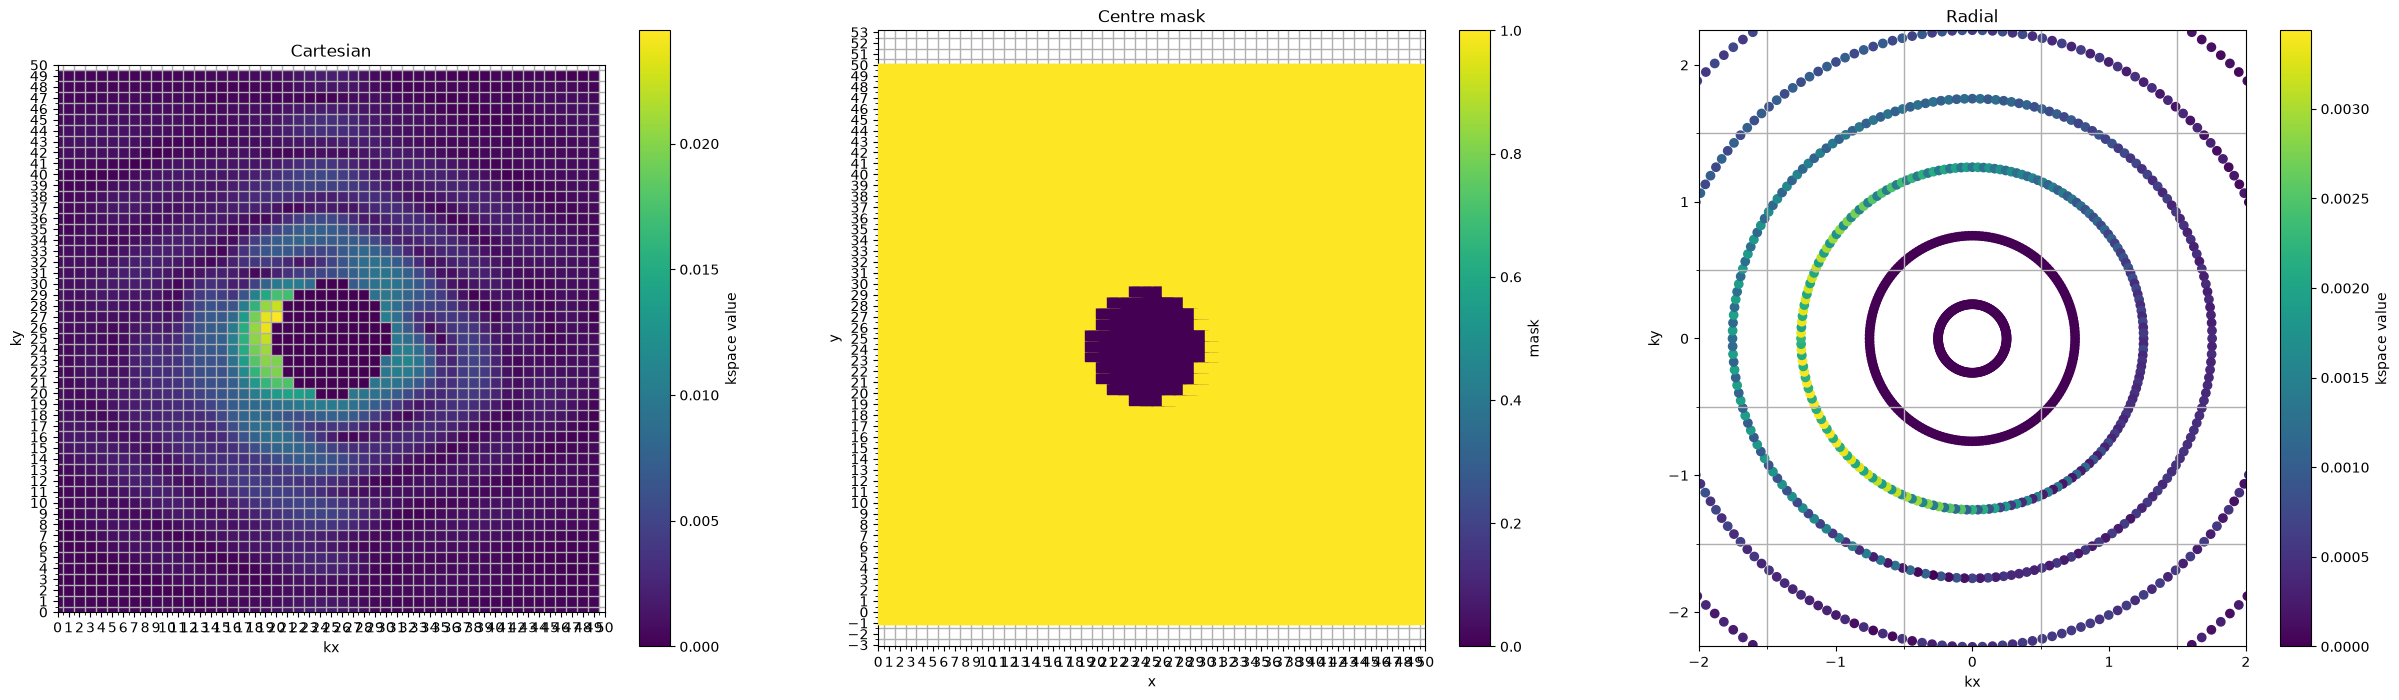

In [4]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 5
yy, xx = np.ogrid[:inner_wid, :inner_wid]
maskb = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

maskb[(cx-5):(cx+6), cy] = False
maskb[(cx), (cy-5):(cy+6)] = False

inner_removedb = inner_region.copy()
inner_removedb[:,~maskb] = 0



asm.plot_mask(inner_removedb, mask=maskb, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=25,sidelenrad=4)


In [ ]:
def softimpute_ALS_time(X_H, M_H, rank, lamda, n_iters):
    I = np.eye(rank)
    m, n = np.shape(X_H)
    U = np.random.randn(m, rank) + 1j * np.random.randn(m, rank)
    V = np.random.randn(n, rank) + 1j * np.random.randn(n, rank)

    D = I.copy()

    A = np.dot(U, D)
    B = np.dot(V, D)
    iter_count = 0
    ABt = A @ B.conj().T

    iter_times = []
    t_total_start = time.perf_counter()

    while iter_count < n_iters:
        t_start = time.perf_counter()

        X_star = np.where(M_H, X_H, ABt)
        X_star1H = X_star.copy()
        A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
        ABt = A @ B.conj().T
        X_star = np.where(M_H, X_H, ABt)
        B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)
        ABt = A @ B.conj().T
        iter_count += 1

        t_elapsed = time.perf_counter() - t_start
        iter_times.append(t_elapsed)

    t_total = time.perf_counter() - t_total_start
    t_mean = np.mean(iter_times)

    return (ABt, X_star1H, t_total, t_mean, iter_times)



def LORAKS_loop_timing(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask, stride, im_dim):
    ksp_forhankel = cartesian_inputkspace.copy()
    iter_count = 0
    deltas = []
    k_prev = None
    timings = {"hankel": [], "svd": [], "unlift": [], "consistency": [], "iter_total": [], "total": []}
    hankel_size = []
    t_loop_start = time.perf_counter()
    while iter_count < n_iters:
        t0 = time.perf_counter()

        hankel_matrix, n_coils, Numx, Numy = asm.hankel_2(kspace=ksp_forhankel, w=window_size, s=stride)
        t1 = time.perf_counter()

        U, S_reduced, Vh = asm.sig_val_thresholding_jax(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh
        data_recon = jx.block_until_ready(data_recon)
        t2 = time.perf_counter()

        kspace_cart_coils_recon = asm.hankel_H_averaged_2(
            data_recon, n_coils=ksp_forhankel.shape[0],
            Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2],
            w=window_size, s=stride)
        t3 = time.perf_counter()

        kspace_cart_coils_consistent = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
        ksp_forhankel = np.asarray(kspace_cart_coils_consistent)  # ensure NumPy, on-host
        t4 = time.perf_counter()

        vec = ksp_forhankel[:, ~dtg_mask]
        if k_prev is not None:
            deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
        k_prev = vec.copy()

        timings["hankel"].append(t1 - t0)
        timings["svd"].append(t2 - t1)
        timings["unlift"].append(t3 - t2)
        timings["consistency"].append(t4 - t3)
        timings["iter_total"].append(t4 - t0)
        hankel_size.append(hankel_matrix.shape)

        iter_count += 1
    t_loop_end = time.perf_counter()
    timings["total"].append(t_loop_end - t_loop_start)
    output_kspace = ksp_forhankel.copy()
    filled_ksp = asm.rebuild(output_kspace=output_kspace, inner_mask=inner_mask,inner_start=start, inner_end=end,enlarged_kspace=cartesian_kspace_enl,resize_x=im_dim, resize_y=im_dim)
    im_grid0 = sp.ifft(filled_ksp, axes=(-2, -1))
    im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

    return (im_0, filled_ksp, deltas, timings, hankel_size)

In [ ]:
def softimpute_ALS(X_H, M_H, rank, lamda, n_iters):
        I = np.eye(rank)
        m,n = np.shape(X_H)
        U = np.random.randn(m, rank) + 1j * np.random.randn(m, rank)
        V = np.random.randn(n, rank) + 1j * np.random.randn(n, rank)

        D = I.copy()


        A = np.dot(U,D)
        B = np.dot(V,D)
        iter_count = 0
        ABt = A @ B.conj().T
        
        while iter_count < n_iters:
            X_star = np.where(M_H, X_H, ABt)
            X_star1H = X_star.copy()
            A = X_star @ B @ np.linalg.inv(B.conj().T @ B + lamda*I)
            ABt = A @ B.conj().T
            X_star = np.where(M_H, X_H, ABt)
            B = X_star.conj().T @ A @ np.linalg.inv(A.conj().T @ A + lamda*I)
            ABt = A @ B.conj().T
            iter_count += 1
        return(ABt, X_star1H)

def LORAKS_imputeals(n_iters, window_size, cartesian_inputkspace, dtg_mask, rank, lamda, stride, im_dim):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_zerod = ksp_forhankel * dtg_mask
    hankel_matrix, n_coils, Numx, Numy = asm.hankel_2(kspace=ksp_zerod, w=window_size, s=stride)
    mask_coiled = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
    masked_hankel, *_ = asm.hankel_2(kspace=mask_coiled, w=window_size, s=stride)
    masked_hankel = np.real(masked_hankel) > 0.5
    
    
    filled_hankel, X_star1, t_total, t_mean, iter_times = softimpute_ALS_time(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lamda, n_iters=n_iters)

    kspace_cart_coils_recon = asm.hankel_H_averaged_2(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size, s=stride)
    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    output_kspace = kspace_cart_coils_recon.copy()
    filled_ksp = asm.rebuild(output_kspace=output_kspace, inner_mask = inner_mask, inner_start = start, inner_end = end, enlarged_kspace=cartesian_kspace_enl, resize_x = im_dim, resize_y = im_dim)
    im_grid0 = sp.ifft(filled_ksp, axes=(-2, -1))
    im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5

    return (im_0, filled_ksp, masked_hankel, t_total, t_mean, iter_times)



def LORAKS_loop(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask, stride, im_dim):
    ksp_forhankel = cartesian_inputkspace.copy()
    iter_count = 0
    deltas = []
    k_prev = None
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel_2(kspace=ksp_forhankel, w=window_size,s=stride)
        #mask_coiled = np.broadcast_to(dtg_mask, (cartesian_inputkspace.shape))
        #masked_hankel, *_ = asm.hankel_2(kspace=mask_coiled, w=window_size, s=stride)
        #masked_hankel = np.real(masked_hankel) > 0.5

        U, S_reduced, Vh = asm.sig_val_thresholding_jax(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh

        kspace_cart_coils_recon = asm.hankel_H_averaged_2(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size, s=stride)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
        ksp_forhankel = kspace_cart_coils_consistent   

        vec = ksp_forhankel[:, ~dtg_mask]

        if k_prev is not None:
            deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
        k_prev = vec.copy()
        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    filled_ksp = asm.rebuild(output_kspace=output_kspace, inner_mask = inner_mask, inner_start = start, inner_end = end, enlarged_kspace=cartesian_kspace_enl, resize_x = im_dim, resize_y = im_dim)
    im_grid0 = sp.ifft(filled_ksp, axes=(-2, -1))
    im_0 = np.sum(np.abs(im_grid0)**2, axis=0)**0.5
    
    return(im_0, filled_ksp, deltas)

## Testing

In [ ]:
import time

timings = {'als': [], 'svd': []}
t0 = time.perf_counter()
im_als, output_kspaceals, zeroed, total_time, mean_time, raw_times = LORAKS_imputeals(n_iters=100, window_size=10, cartesian_inputkspace=inner_region, dtg_mask=maskb, rank= 10, lamda = 5*10**-5, stride=1, im_dim=256)
t1 = time.perf_counter()
timings['als'].append(t1 - t0)

print(f"Als done in {t1-t0}")

t2 = time.perf_counter()
ims_svd, output_kspacesvd, deltas, svdtimes, hankelshape = LORAKS_loop_timing(n_iters=100, window_size=5, zero_thresh=0.2,cartesian_inputkspace=inner_region, dtg_mask=maskb, stride=1, im_dim=256)
t3 = time.perf_counter()
#timings['svd'].append(t3-t2)

print(f"SVD done in {t3-t2}")

svdtimes_cleaned = {key: float(np.mean(times[1:])) for key, times in svdtimes.items()}

print(svdtimes_cleaned)
print(mean_time)

test_results = {'2 points removed':preloop, 'als, window:10 ,rank:10, lam:5e-5':im_als, 'svd, window:5, zerthresh:0.2': ims_svd,'nogap':img_nogap}

asm.diff_matrix(test_results, title=f'100 Iterations, Stride of 1.')

## Iter_countSDV

In [ ]:
iter_count = {'30_iters': 30, '50_iters': 50, '75_iters': 75, '100_iters': 100}
window_size = 5
stride_len = 1
num_iters = 50
thresh=0.2
cartesian_input = inner_region.copy()

results = {}
results['preloop'] = {'im': preloop} 
for name, iters in iter_count.items():
    im, cart, delta = LORAKS_loop(iters, window_size, thresh, cartesian_input, maskb, stride_len, 256, 256)
    results[name] = {'im': im}

results['nogap'] = {'im': img_nogap}

imsvd = {f'itercount {r}': results[r]['im'] for r in results}
asm.diff_matrix(imsvd)

## IterCount ALS

In [ ]:
iter_count = {'50_iters': 50, '75_iters': 75, '100_iters': 100}
win = 10
stride_len = 1
thresh=0.2
cartesian_input = inner_region.copy()

results = {}
results['preloop'] = {'im': preloop} 
for name, iters in iter_count.items():
    im_als, cart, delta = LORAKS_imputeals(n_iters = iters,window_size=win, cartesian_inputkspace = cartesian_input, dtg_mask = maskb, rank=10,lamda=5*10**-5, stride=1, im_dim=256)
    results[name] = {'im': im_als}

results['nogap'] = {'im': img_nogap}

imsals = {f'rank_val {r}': results[r]['im'] for r in results}
asm.diff_matrix(imsals)

## Stridelen ALS

In [ ]:
stridelen = {'Stride of 1': 1, 'Stride of 2': 2, 'Stride of 3': 3, 'Stride of 4': 4, 'Stride of 5': 5}
win = 10
cartesian_input = inner_region.copy()

results = {}
results['preloop'] = {'im': preloop} 
for name, stride in stridelen.items():
    im_als= LORAKS_imputeals(n_iters = 100,window_size=win, cartesian_inputkspace = cartesian_input, dtg_mask = maskb, rank=10,lamda=5*10**-5, stride=stride, im_dim=256)
    results[name] = {'im': im_als}

results['nogap'] = {'im': img_nogap}

imsals = {f'rank_val {r}': results[r]['im'] for r in results}
asm.diff_matrix(imsals)